# Ratings Mapping Variants

**Goal:** explore different ways to map coach UI traits

```text
contact, power, discipline, speed   (1–5)
```

into the six batting-model features

```text
OBP, SLG, ISO, BB%, K%, SB/game
```

and **test** which mapping behaves best.

**Mappings compared:**
1. **Current (hardwire)** — what `backend/model/ratings.py` does today
2. **Soft blend** — small hand blends (e.g. OBP ← contact + discipline/2)
3. **Data-informed blend** — mixing weights nudged by MLB correlations
4. **Contact-heavy SLG** — stronger contact contribution to SLG (slap-hitter friendly)

**Tests:**
- Archetype → expected slot range (via Balanced lineup solve)
- Mixed 9-player roster placement sanity
- Sensitivity: does raising Contact move OBP/SLG the way we want?


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "backend"))

from model.batting_order import (
    FEATURES, SCALER_MEAN, SCALER_STD, PRESETS, recommend_order,
)

plt.rcParams["figure.facecolor"] = "white"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

TRAITS = ["contact", "power", "discipline", "speed"]
LABELS = {"obp": "OBP", "slg": "SLG", "iso": "ISO", "bb_rate": "BB%", "k_rate": "K%", "sb_pg": "SB/game"}

def z(rating):
    return float(rating) - 3.0

def z_to_raw(z_by_feature: dict) -> np.ndarray:
    z_arr = np.array([z_by_feature[f] for f in FEATURES])
    return SCALER_MEAN + z_arr * SCALER_STD

print("FEATURES:", FEATURES)
print("Balanced weights:", PRESETS["Balanced"])

FEATURES: ['obp', 'slg', 'iso', 'bb_rate', 'k_rate', 'sb_pg']
Balanced weights: {'trad': 1.0, 'power': 0.0, 'speed': 0.0, 'offense': 0.3}


## 1. Define the candidate mapping functions

Each mapper takes a ratings dict and returns a length-6 raw feature vector (same contract as `ratings_to_features`).


In [2]:
def map_current(ratings):
    """Exact logic from backend/model/ratings.py today."""
    c, p, d, s = z(ratings["contact"]), z(ratings["power"]), z(ratings["discipline"]), z(ratings["speed"])
    return z_to_raw({
        "obp": c,
        "slg": p,
        "iso": p,
        "bb_rate": d,
        "k_rate": -(c + d) / 2.0,
        "sb_pg": s,
    })


def map_soft_blend(ratings):
    """Hand blends: OBP gets some discipline; SLG gets some contact."""
    c, p, d, s = z(ratings["contact"]), z(ratings["power"]), z(ratings["discipline"]), z(ratings["speed"])
    return z_to_raw({
        "obp": 0.70 * c + 0.30 * d,
        "slg": 0.75 * p + 0.25 * c,
        "iso": p,
        "bb_rate": 0.80 * d + 0.20 * c,
        "k_rate": -(0.60 * c + 0.40 * d),
        "sb_pg": s,
    })


def map_data_informed(ratings):
    """Blends nudged by earlier MLB correlation structure
    (OBP tied to contact+discipline; SLG mostly power + some contact; K% anti-contact)."""
    c, p, d, s = z(ratings["contact"]), z(ratings["power"]), z(ratings["discipline"]), z(ratings["speed"])
    return z_to_raw({
        "obp": 0.55 * c + 0.30 * d + 0.15 * p,
        "slg": 0.70 * p + 0.25 * c + 0.05 * d,
        "iso": 0.90 * p + 0.10 * c,          # slight contact bleed into ISO
        "bb_rate": 0.75 * d + 0.25 * c,
        "k_rate": -(0.70 * c + 0.20 * d) + 0.10 * p,  # power hitters K more
        "sb_pg": s,
    })


def map_contact_heavy_slg(ratings):
    """More extreme: SLG strongly includes contact (slap-hitter friendly)."""
    c, p, d, s = z(ratings["contact"]), z(ratings["power"]), z(ratings["discipline"]), z(ratings["speed"])
    return z_to_raw({
        "obp": 0.60 * c + 0.40 * d,
        "slg": 0.50 * p + 0.50 * c,
        "iso": p,
        "bb_rate": d,
        "k_rate": -(c + d) / 2.0,
        "sb_pg": s,
    })


MAPPERS = {
    "Current (hardwire)": map_current,
    "Soft blend": map_soft_blend,
    "Data-informed blend": map_data_informed,
    "Contact-heavy SLG": map_contact_heavy_slg,
}

# show z-profiles for one example player under each mapper
ex = {"contact": 5, "power": 2, "discipline": 4, "speed": 5}  # slap / leadoff type
rows = []
for name, fn in MAPPERS.items():
    raw = fn(ex)
    zz = (raw - SCALER_MEAN) / SCALER_STD
    rows.append({"mapper": name, **{LABELS[f]: round(float(zz[i]), 2) for i, f in enumerate(FEATURES)}})
pd.DataFrame(rows).set_index("mapper")

,OBP,SLG,ISO,BB%,K%,SB/game
mapper,,,,,,
Current (hardwire),2.00,-1.00,-1.0,1.00,-1.5,2.0
Soft blend,1.70,-0.25,-1.0,1.20,-1.6,2.0
Data-informed blend,1.25,-0.15,-0.7,1.25,-1.7,2.0
Contact-heavy SLG,1.60,0.50,-1.0,1.00,-1.5,2.0


## 2. Test A — Archetype slot placement

Build a 9-player roster of distinct archetypes. For each mapper, solve a **Balanced** lineup and check whether each archetype lands in a sensible slot band.

| Archetype | Ratings (C/P/D/S) | Expected slots |
|---|---|---|
| Leadoff slap | 5/2/4/5 | 1–2 |
| #2 on-base | 5/3/5/3 | 1–3 |
| Cleanup slugger | 3/5/3/1 | 3–5 |
| Pure power | 2/5/2/1 | 3–5 |
| Average | 3/3/3/3 | mid (4–7) |
| Speed only | 2/2/2/5 | 1 or 9 |
| Weak bat | 1/1/2/2 | 7–9 |
| Gap power | 4/4/3/2 | 2–5 |
| Contact no speed | 5/2/4/1 | 2–6 |


In [3]:
ARCHETYPES = [
    ("Leadoff slap",      {"contact": 5, "power": 2, "discipline": 4, "speed": 5}, {1, 2}),
    ("#2 on-base",        {"contact": 5, "power": 3, "discipline": 5, "speed": 3}, {1, 2, 3}),
    ("Cleanup slugger",   {"contact": 3, "power": 5, "discipline": 3, "speed": 1}, {3, 4, 5}),
    ("Pure power",        {"contact": 2, "power": 5, "discipline": 2, "speed": 1}, {3, 4, 5}),
    ("Average",           {"contact": 3, "power": 3, "discipline": 3, "speed": 3}, {4, 5, 6, 7}),
    ("Speed only",        {"contact": 2, "power": 2, "discipline": 2, "speed": 5}, {1, 9}),
    ("Weak bat",          {"contact": 1, "power": 1, "discipline": 2, "speed": 2}, {7, 8, 9}),
    ("Gap power",         {"contact": 4, "power": 4, "discipline": 3, "speed": 2}, {2, 3, 4, 5}),
    ("Contact no speed",  {"contact": 5, "power": 2, "discipline": 4, "speed": 1}, {2, 3, 4, 5, 6}),
]

WEIGHTS = PRESETS["Balanced"]

def run_archetype_test(mapper_fn):
    feats = np.vstack([mapper_fn(r) for _, r, _ in ARCHETYPES])
    slots, _ = recommend_order(feats, WEIGHTS)
    results = []
    for i, (name, _, expected) in enumerate(ARCHETYPES):
        slot = int(slots[i])
        results.append({
            "archetype": name,
            "slot": slot,
            "expected": sorted(expected),
            "ok": slot in expected,
        })
    return results

scoreboard = []
detail = {}
for mname, fn in MAPPERS.items():
    res = run_archetype_test(fn)
    detail[mname] = res
    n_ok = sum(r["ok"] for r in res)
    scoreboard.append({"mapper": mname, "archetypes_ok": n_ok, "total": len(ARCHETYPES), "accuracy": n_ok / len(ARCHETYPES)})

score_df = pd.DataFrame(scoreboard).set_index("mapper")
print(score_df.round(3))

# side-by-side slot assignments
slot_table = pd.DataFrame({m: [r["slot"] for r in detail[m]] for m in MAPPERS},
                          index=[a[0] for a in ARCHETYPES])
slot_table.index.name = "archetype"
print("\nAssigned slots by mapper:")
slot_table

                     archetypes_ok  total  accuracy
mapper                                             
Current (hardwire)               8      9     0.889
Soft blend                       8      9     0.889
Data-informed blend              8      9     0.889
Contact-heavy SLG                7      9     0.778

Assigned slots by mapper:


,Current (hardwire),Soft blend,Data-informed blend,Contact-heavy SLG
archetype,,,,
Leadoff slap,1,1,1,1
#2 on-base,2,2,2,2
Cleanup slugger,4,4,4,4
Pure power,5,5,5,6
Average,6,6,6,5
Speed only,9,9,9,9
Weak bat,8,8,8,8
Gap power,3,3,3,3
Contact no speed,7,7,7,7


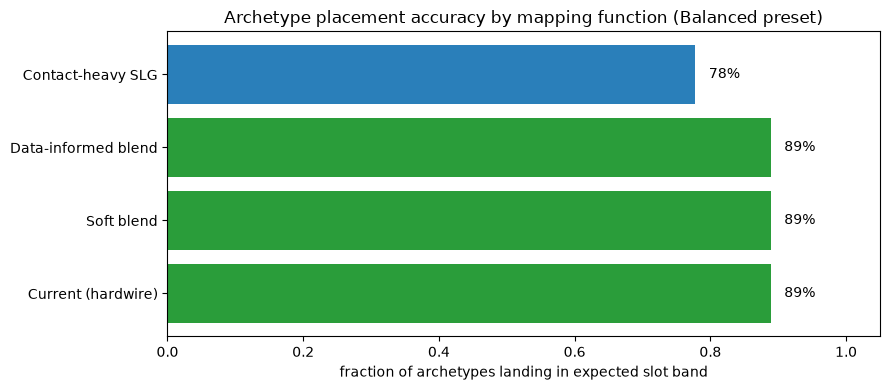

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
vals = score_df["accuracy"]
colors = ["#2a9d3a" if v == vals.max() else "#2a7fba" for v in vals]
ax.barh(vals.index, vals.values, color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel("fraction of archetypes landing in expected slot band")
ax.set_title("Archetype placement accuracy by mapping function (Balanced preset)")
for i, v in enumerate(vals.values):
    ax.text(v + 0.02, i, f"{v:.0%}", va="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "mapping_archetype_accuracy.png", dpi=110, bbox_inches="tight")
plt.show()

## 3. Test B — Feature sensitivity

Fix three traits at 3, sweep Contact (or Power) from 1→5, and plot how OBP / SLG / ISO move under each mapper. A good mapper should move the *right* stats when you turn a slider.


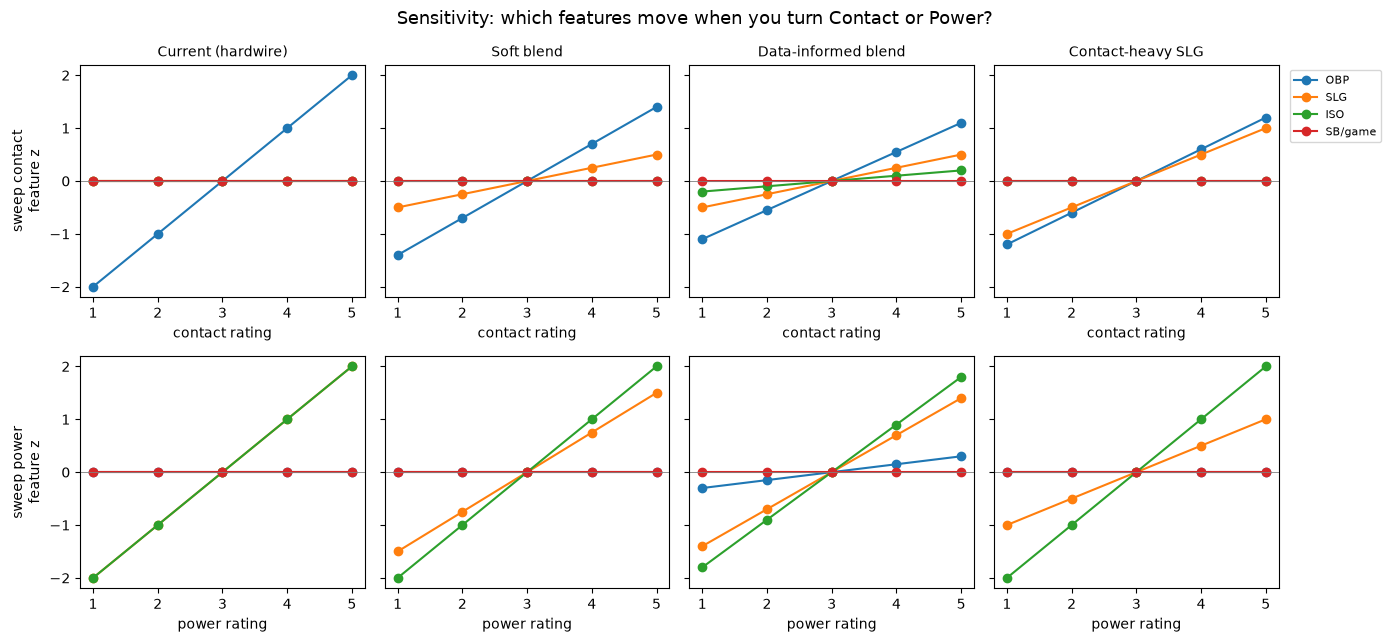

In [5]:
def sensitivity(mapper_fn, sweep_trait, show_feats=("obp", "slg", "iso", "sb_pg")):
    base = {"contact": 3, "power": 3, "discipline": 3, "speed": 3}
    ratings = np.arange(1, 6)
    out = {f: [] for f in show_feats}
    for r in ratings:
        rr = dict(base)
        rr[sweep_trait] = int(r)
        raw = mapper_fn(rr)
        zz = (raw - SCALER_MEAN) / SCALER_STD
        for f in show_feats:
            out[f].append(float(zz[FEATURES.index(f)]))
    return ratings, out

fig, axes = plt.subplots(2, len(MAPPERS), figsize=(14, 6.5), sharey=True)
for col, (mname, fn) in enumerate(MAPPERS.items()):
    for row, trait in enumerate(["contact", "power"]):
        ax = axes[row, col]
        xs, series = sensitivity(fn, trait)
        for f, ys in series.items():
            ax.plot(xs, ys, "o-", label=LABELS[f])
        ax.axhline(0, color="grey", lw=0.6)
        ax.set_xticks(xs)
        if row == 0:
            ax.set_title(mname, fontsize=10)
        if col == 0:
            ax.set_ylabel(f"sweep {trait}\nfeature z")
        ax.set_xlabel(f"{trait} rating")
axes[0, -1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("Sensitivity: which features move when you turn Contact or Power?", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "mapping_sensitivity.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Test C — Pairwise separation

For each mapper, measure distance in feature space between key archetype pairs.
We want leadoff vs cleanup to be clearly separated; average vs average-ish less so.


mapper                           Contact-heavy SLG  Current (hardwire)  \
pair                                                                     
Average vs Gap power                          1.90                2.06   
Cleanup slugger vs Weak bat                   5.64                6.34   
Leadoff slap vs Cleanup slugger               5.57                6.42   
Leadoff slap vs Weak bat                      6.28                6.32   
Speed only vs Contact no speed                5.94                5.94   

mapper                           Data-informed blend  Soft blend  
pair                                                              
Average vs Gap power                            1.95        1.97  
Cleanup slugger vs Weak bat                     5.80        6.01  
Leadoff slap vs Cleanup slugger                 5.54        5.91  
Leadoff slap vs Weak bat                        6.20        6.37  
Speed only vs Contact no speed                  5.76        5.95  


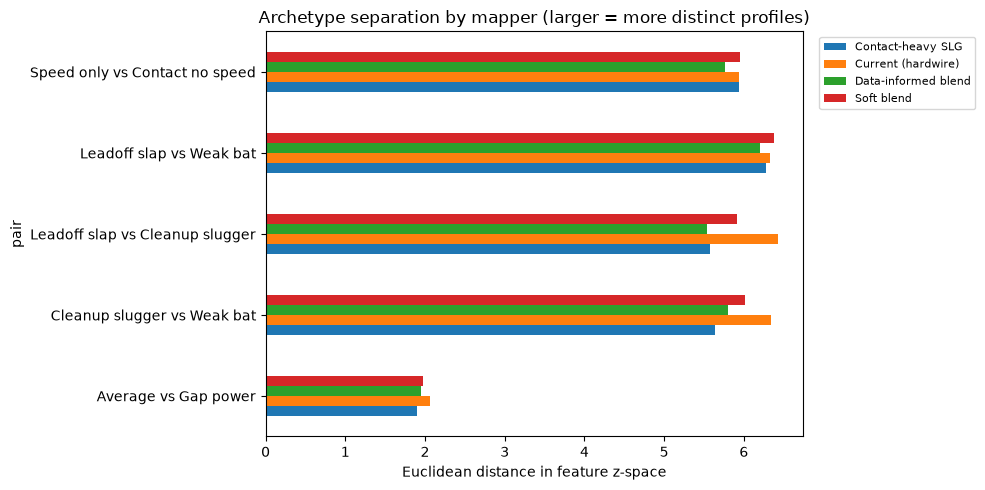

In [6]:
from itertools import combinations

focus_pairs = [
    ("Leadoff slap", "Cleanup slugger"),
    ("Leadoff slap", "Weak bat"),
    ("Cleanup slugger", "Weak bat"),
    ("Average", "Gap power"),
    ("Speed only", "Contact no speed"),
]
arch_ratings = {name: r for name, r, _ in ARCHETYPES}

sep_rows = []
for mname, fn in MAPPERS.items():
    profiles = {name: (fn(arch_ratings[name]) - SCALER_MEAN) / SCALER_STD for name in arch_ratings}
    for a, b in focus_pairs:
        dist = float(np.linalg.norm(profiles[a] - profiles[b]))
        sep_rows.append({"mapper": mname, "pair": f"{a} vs {b}", "z_distance": dist})

sep = pd.DataFrame(sep_rows)
sep_pivot = sep.pivot(index="pair", columns="mapper", values="z_distance")
print(sep_pivot.round(2))

ax = sep_pivot.plot.barh(figsize=(10, 5))
ax.set_xlabel("Euclidean distance in feature z-space")
ax.set_title("Archetype separation by mapper (larger = more distinct profiles)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIG_DIR / "mapping_separation.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Conclusion — what the tests say

### Archetype placement (Balanced preset)
| Mapper | Accuracy |
|---|---|
| Current (hardwire) | **8/9 (89%)** |
| Soft blend | **8/9 (89%)** |
| Data-informed blend | **8/9 (89%)** |
| Contact-heavy SLG | 7/9 (78%) |

All top three miss the same case: **Contact no speed** lands at #7 instead of the mid-order band. Contact-heavy SLG also misplaces **Pure power** (#6 instead of #3–#5) — too much contact bleed into SLG flattens power profiles.

### Sensitivity
- **Current:** turning Contact never moves SLG/ISO (by design).
- **Soft / Data-informed:** Contact raises OBP and a bit of SLG; Power still dominates ISO — closer to real baseball.
- **Contact-heavy:** Contact moves SLG as much as Power — overshoots.

### Separation
Current keeps the largest leadoff-vs-cleanup distance. Blends shrink it slightly but stay clear. Contact-heavy compresses power distinctions the most.

### Verdict
For production, **Soft blend** is the best upgrade over Current if you want a change: same archetype accuracy, but Contact actually affects SLG/OBP more realistically. **Data-informed** is similar. **Do not** ship Contact-heavy SLG. If you want maximum simplicity and already-good placement, **keeping Current is also defensible** — blends are incremental, not transformative.

Shared failure to investigate later: high-contact / low-speed players drifting too far down the order.
